In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib widget

In [2]:
target_x = [1]
target_y = [1]
target_z = [1]

In [3]:
with open("../output/test.json") as datafile:
    data = json.loads(datafile.read())
data = data['data']

In [4]:
df = pd.json_normalize(data)
df.head()

,timestep,datapoint.position.x,datapoint.position.y,datapoint.position.z,datapoint.velocity.x,datapoint.velocity.y,datapoint.velocity.z,datapoint.acceleration.x,datapoint.acceleration.y,datapoint.acceleration.z,datapoint.mass
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,1
1,0.05,0.000000,0.000000,0.010000,0.000000,0.000000,0.200000,0.007817,0.007817,-0.007083,1
2,0.10,0.000000,0.000000,0.020000,0.000391,0.000391,0.199646,0.015713,0.015713,-0.014166,1
3,0.15,0.000020,0.000020,0.029982,0.001177,0.001177,0.198938,0.023657,0.023657,-0.021226,1
4,0.20,0.000078,0.000078,0.039929,0.002359,0.002359,0.197876,0.031619,0.031619,-0.028238,1


In [5]:
time = df['timestep']
x = df['datapoint.position.x']
y = df['datapoint.position.y']
z = df['datapoint.position.z']

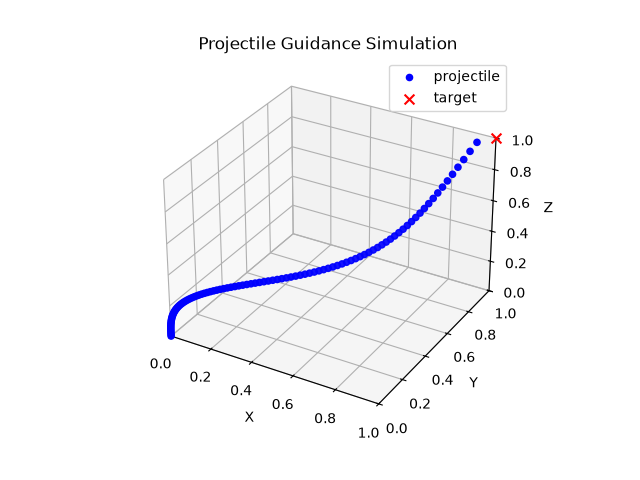

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter([],[], [], c='b', marker='o', label='projectile')
target = ax.scatter([], [], [], c='r', marker='x', s=50, label='target')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Projectile Guidance Simulation')
ax.legend(loc="upper right")

def init():
    scatter._offsets3d = ([], [], [])
    target._offset3d = ([], [], [])
    return scatter, target

def update(frame):
    scatter._offsets3d = (x[:frame+1], y[:frame+1], z[:frame+1])
    target._offsets3d = (target_x, target_y, target_z)
    ax.set_xlim(0, max(target_x))
    ax.set_ylim(0, max(target_y))
    ax.set_zlim(0, max(target_z))
    return scatter, target

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(df),
    init_func=init,
    blit=False,
    interval=50,  # Delay between frames in milliseconds
    repeat=False
)

ani.save('../output/animation.mp4', writer='ffmpeg', fps=30, dpi=200)
plt.show()